In [ ]:
# Análisis Estadístico — Metáforas Espaciales

**Diseño:** Intra-sujeto (cada participante realizó ambas condiciones)

**Estructura:**
1. Importar librerías
2. Cargar archivos CSV y Excel desde `data/Sujetos/`
3. Unir bases
4. Limpiar tipos de datos
5. Descriptivos por condición
6. Promedios por participante
7. Shapiro-Wilk sobre diferencias
8. Correcto/Incorrecto — descriptivo
9. Análisis exploratorio por sexo
10. Selección de prueba inferencial

In [1]:
# ============================================================
# SECCIÓN 1: IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías cargadas correctamente.")

/Users/sabrina/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Librerías cargadas correctamente.


---
## Secciones 2 & 3: Cargar archivos y unir bases

Lee todos los `.csv` y `.xlsx` / `.xls` de `data/Sujetos/` y los concatena en un único DataFrame.

In [2]:
# ============================================================
# SECCIONES 2 & 3: CARGAR ARCHIVOS DESDE data/Sujetos/ Y UNIR
# Soporta .csv, .xlsx y .xls; ignora cualquier otro archivo
# ============================================================

data_dir = Path('data/Sujetos')
frames = []

for archivo in sorted(data_dir.iterdir()):
    ext = archivo.suffix.lower()
    if ext == '.csv':
        df_temp = pd.read_csv(archivo)
    elif ext in ('.xlsx', '.xls'):
        df_temp = pd.read_excel(archivo)
    else:
        continue  # ignora .DS_Store y otros archivos no tabulares

    df_temp['archivo_fuente'] = archivo.name
    frames.append(df_temp)
    print(f"  ✓  {archivo.name}  ({len(df_temp)} filas, {df_temp.shape[1]} columnas)")

df = pd.concat(frames, ignore_index=True)

print(f"\nBase unificada: {len(df)} filas × {df.shape[1]} columnas")
print(f"Participantes únicos: {df['participante'].nunique()}")
print(f"Tipos de metáfora encontrados: {df['tipo_metafora'].unique().tolist()}")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")

  ✓  001_Metaforas_Espaciales_20260510_110659.csv  (32 filas, 21 columnas)
  ✓  002_Metaforas_Espaciales_20260511_152154.csv  (32 filas, 21 columnas)
  ✓  003_Metaforas_Espaciales_20260512_111159.csv  (32 filas, 21 columnas)
  ✓  004_Metaforas_Espaciales_20260519_235524.csv  (32 filas, 21 columnas)
  ✓  005_Metaforas_Espaciales_20260518_141937.xlsx  (32 filas, 22 columnas)
  ✓  006_Metaforas_Espaciales_20260518_135332.xlsx  (32 filas, 22 columnas)
  ✓  007_Metaforas_Espaciales_20260519_093258.xlsx  (32 filas, 22 columnas)

Base unificada: 224 filas × 22 columnas
Participantes únicos: 7
Tipos de metáfora encontrados: ['determinada', 'indeterminada']

Columnas disponibles:
['participante', 'edad', 'sexo', 'num_ensayo', 'tipo_metafora', 'texto_metafora', 'relacion', 'sujeto', 'objeto', 'palabras_presentadas', 'q_sujeto_participante', 'q_objeto_participante', 'config_valida', 'configs_validas', 'total_score', 'parcial_score', 'respuesta_boton', 'rt_lectura_s', 'rt_inferencia_s', 'fecha_hor

---
## Sección 4: Limpiar tipos de datos

In [3]:
# ============================================================
# SECCIÓN 4: LIMPIAR TIPOS DE DATOS
# ============================================================

# Participante → string con ceros a la izquierda (ej. '005')
# Maneja tanto enteros como strings como floats
df['participante'] = df['participante'].apply(
    lambda x: str(int(float(x))).zfill(3) if pd.notna(x) else x
)

# tipo_metafora → minúsculas sin espacios para consistencia
df['tipo_metafora'] = df['tipo_metafora'].astype(str).str.strip().str.lower()

# config_valida → booleano (maneja True/False como string, int o bool)
df['config_valida'] = df['config_valida'].map(
    {True: True, False: False, 'True': True, 'False': False, 1: True, 0: False}
)

# Variables numéricas continuas (coerce convierte errores a NaN)
VARS_CONTINUAS = ['rt_lectura_s', 'rt_inferencia_s', 'total_score', 'parcial_score']
for col in VARS_CONTINUAS + ['edad']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Lista de variables realmente presentes en los datos
VARS_ANALISIS = [v for v in VARS_CONTINUAS if v in df.columns]

print("Tipos de datos tras limpieza:")
print(df[['participante', 'tipo_metafora', 'config_valida'] + VARS_ANALISIS].dtypes)
print(f"\nDistribución de tipo_metafora:\n{df['tipo_metafora'].value_counts()}")
print(f"\nParticipantes: {sorted(df['participante'].unique())}")
print(f"\nVariables a analizar: {VARS_ANALISIS}")
print(f"\nNaN por columna:\n{df[VARS_ANALISIS].isna().sum()}")

Tipos de datos tras limpieza:
participante        object
tipo_metafora       object
config_valida         bool
rt_lectura_s       float64
rt_inferencia_s    float64
total_score        float64
parcial_score      float64
dtype: object

Distribución de tipo_metafora:
tipo_metafora
determinada      112
indeterminada    112
Name: count, dtype: int64

Participantes: ['001', '002', '003', '004', '005', '006', '007']

Variables a analizar: ['rt_lectura_s', 'rt_inferencia_s', 'total_score', 'parcial_score']

NaN por columna:
rt_lectura_s       0
rt_inferencia_s    0
total_score        0
parcial_score      0
dtype: int64


---
## Sección 5: Descriptivos por condición

Media, desviación estándar, mediana y rango intercuartílico para cada variable, separado por tipo de metáfora.  
> Nota: estos descriptivos incluyen todos los ensayos. Las pruebas inferenciales se harán sobre los **promedios por participante** (Sección 6).

DESCRIPTIVOS POR TIPO DE METÁFORA  (media, SD, mediana, RIQ)
              rt_lectura_s                                rt_inferencia_s                              total_score                                   parcial_score                                 
                         n   media      sd mediana    riq               n  media     sd mediana    riq           n   media      sd  mediana      riq             n   media      sd  mediana     riq
tipo_metafora                                                                                                                                                                                      
determinada            112 16.2392 46.8321  6.7416 6.1564             112 6.1264 3.8451  5.1910 2.4346         112 88.3929 32.1750 100.0000   0.0000           112 91.9643 26.4691 100.0000  0.0000
indeterminada          112 14.4242 33.8763  6.8786 6.4917             112 6.1028 5.0569  5.1682 2.7142         112 66.9643 47.2456 100.0000 100.0000       

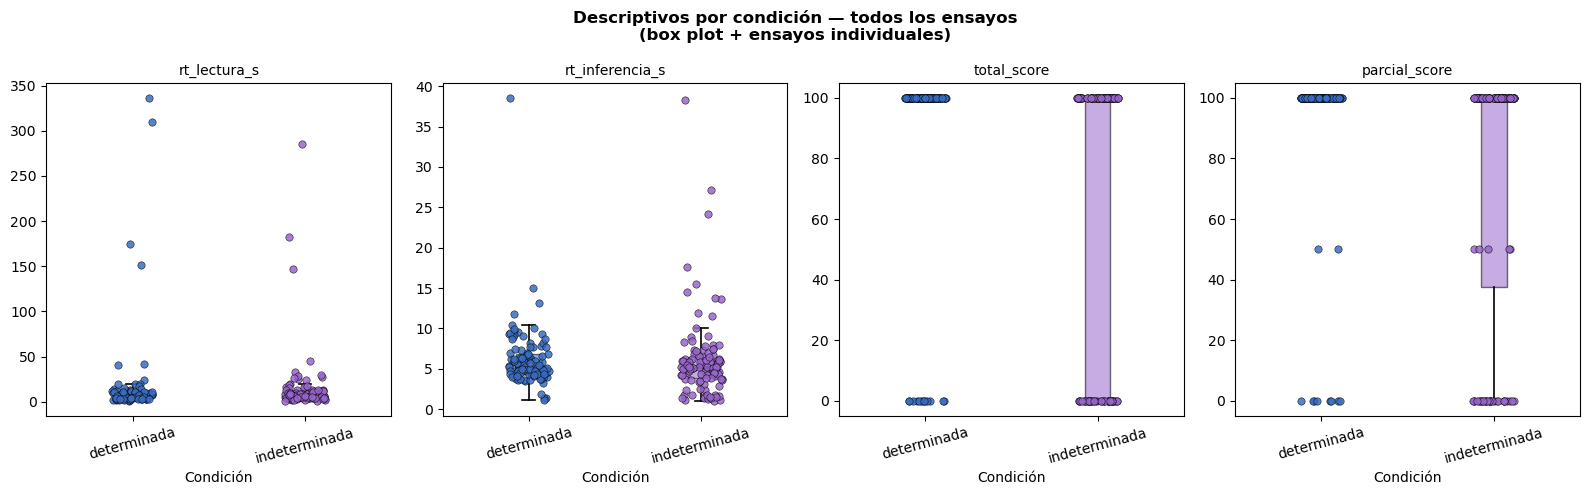


[Las pruebas inferenciales se harán sobre promedios por participante — ver Sección 6.]


In [12]:
# ============================================================
# SECCIÓN 5: DESCRIPTIVOS POR CONDICIÓN (todos los ensayos)
# ============================================================

print("=" * 70)
print("DESCRIPTIVOS POR TIPO DE METÁFORA  (media, SD, mediana, RIQ)")
print("=" * 70)

desc_list = []
for var in VARS_ANALISIS:
    desc = df.groupby('tipo_metafora')[var].agg(
        n='count',
        media='mean',
        sd='std',
        mediana='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    desc['riq'] = (desc['q75'] - desc['q25']).round(4)
    desc = desc.drop(columns=['q25', 'q75']).round(4)
    desc.columns = pd.MultiIndex.from_tuples([(var, c) for c in desc.columns])
    desc_list.append(desc)

desc_tabla = pd.concat(desc_list, axis=1)
print(desc_tabla.to_string())

# ── Figuras: box plots + dispersión por condición ────────────
colores_s5 = {'determinada': '#3A6DC2', 'indeterminada': '#9966CC'}
conds = ['determinada', 'indeterminada']
n_vars = len(VARS_ANALISIS)
fig, axes = plt.subplots(1, n_vars, figsize=(4 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for ax, var in zip(axes, VARS_ANALISIS):
    data_plot = [df.loc[df['tipo_metafora'] == c, var].dropna().values for c in conds]
    bp = ax.boxplot(
        data_plot, labels=conds, patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='', markersize=0),  # ocultamos outliers del boxplot
    )
    for patch, cond in zip(bp['boxes'], conds):
        patch.set_facecolor(colores_s5[cond])
        patch.set_alpha(0.55)

    # Puntos individuales con jitter
    for i, (datos, cond) in enumerate(zip(data_plot, conds)):
        jitter = rng.uniform(-0.12, 0.12, size=len(datos))
        ax.scatter(
            i + 1 + jitter, datos,
            color=colores_s5[cond], s=28, alpha=0.85,
            edgecolors='black', linewidths=0.4, zorder=3
        )

    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Condición')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Descriptivos por condición — todos los ensayos\n(box plot + ensayos individuales)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[Las pruebas inferenciales se harán sobre promedios por participante — ver Sección 6.]")

---
## Sección 6: Promedios por participante y condición

Promedio de cada variable por participante × condición.  
Este dataframe (`df_prom`) es la **base para todas las pruebas inferenciales** (diseño intra-sujeto).

PROMEDIOS POR PARTICIPANTE Y CONDICIÓN
participante tipo_metafora  rt_lectura_s  rt_inferencia_s  total_score  parcial_score
         001   determinada        8.4635           5.5854      81.2500        90.6250
         001 indeterminada       11.8905           7.8403      56.2500        59.3750
         002   determinada        9.7363           6.0276      68.7500        71.8750
         002 indeterminada        8.0817           5.9794      56.2500        59.3750
         003   determinada        8.2785           7.3057      87.5000        93.7500
         003 indeterminada       14.6939           8.7966      87.5000        93.7500
         004   determinada       12.6062           7.6209      93.7500        93.7500
         004 indeterminada       10.9618           6.2662      75.0000        78.1250
         005   determinada       17.7035           5.5944      93.7500       100.0000
         005 indeterminada       25.8744           5.0375      87.5000        96.8750
         006   

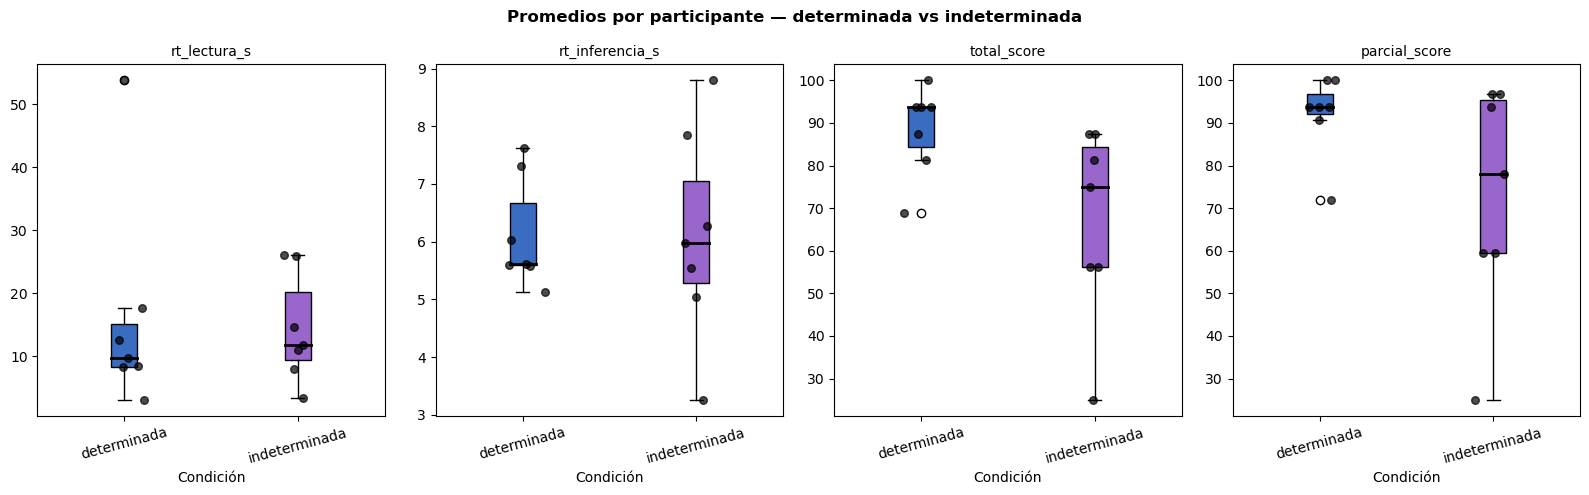

In [15]:
# ============================================================
# SECCIÓN 6: PROMEDIOS POR PARTICIPANTE Y CONDICIÓN
# Base para las pruebas inferenciales (diseño intra-sujeto)
# ============================================================

df_prom = (
    df.groupby(['participante', 'tipo_metafora'])[VARS_ANALISIS]
    .mean()
    .round(4)
    .reset_index()
)

print("=" * 70)
print("PROMEDIOS POR PARTICIPANTE Y CONDICIÓN")
print("=" * 70)
print(df_prom.to_string(index=False))

n_part = df_prom['participante'].nunique()
print(f"\nn participantes = {n_part}")
print(f"Filas esperadas = {n_part} × 2 condiciones = {n_part * 2}")
print(f"Filas obtenidas = {len(df_prom)}")

# ── Figura: box plots + puntos individuales por condición ────
fig, axes = plt.subplots(1, len(VARS_ANALISIS), figsize=(4 * len(VARS_ANALISIS), 5))
if len(VARS_ANALISIS) == 1:
    axes = [axes]

for ax, var in zip(axes, VARS_ANALISIS):
    conds = ['determinada', 'indeterminada']
    data_plot = [
        df_prom.loc[df_prom['tipo_metafora'] == c, var].dropna().values
        for c in conds
    ]
    bp = ax.boxplot(data_plot, labels=conds, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#3A6DC2')
    bp['boxes'][1].set_facecolor('#9966CC')
    for i, datos in enumerate(data_plot):
        ax.scatter(
            np.random.normal(i + 1, 0.05, size=len(datos)), datos,
            color='black', s=30, alpha=0.7, zorder=3
        )
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Condición')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Promedios por participante — determinada vs indeterminada',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 7: Normalidad — Shapiro-Wilk sobre las diferencias

Se convierte `df_prom` a formato ancho para calcular la **diferencia entre condiciones por participante** y se aplica Shapiro-Wilk sobre esas diferencias.

Dirección de las diferencias:
- `diferencia_rt_lectura` = indeterminada − determinada  
- `diferencia_rt_inferencia` = indeterminada − determinada  
- `diferencia_total_score` = determinada − indeterminada  
- `diferencia_parcial_score` = determinada − indeterminada

Columnas en formato ancho:
['participante', 'parcial_score_determinada', 'parcial_score_indeterminada', 'rt_inferencia_s_determinada', 'rt_inferencia_s_indeterminada', 'rt_lectura_s_determinada', 'rt_lectura_s_indeterminada', 'total_score_determinada', 'total_score_indeterminada']

SHAPIRO-WILK SOBRE DIFERENCIAS ENTRE CONDICIONES
(H0: la diferencia por participante sigue distribución normal)
              diferencia  n      W  p_value  normal_p05      interpretacion
   diferencia_rt_lectura  7 0.7485   0.0122       False No normal (p ≤ .05)
diferencia_rt_inferencia  7 0.9482   0.7128        True    Normal (p > .05)
  diferencia_total_score  7 0.8040   0.0448       False No normal (p ≤ .05)
diferencia_parcial_score  7 0.7965   0.0378       False No normal (p ≤ .05)


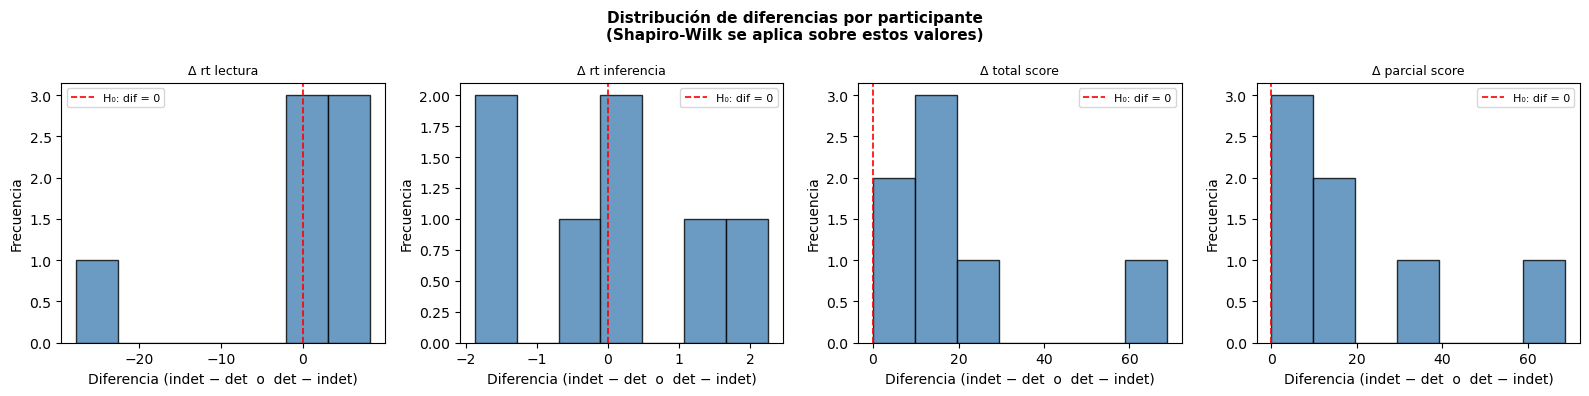

In [6]:
# ============================================================
# SECCIÓN 7: NORMALIDAD — SHAPIRO-WILK SOBRE LAS DIFERENCIAS
# Nivel de análisis: un valor por participante (diseño intra-sujeto)
# ============================================================

# Paso 1: formato ancho — una fila por participante
df_wide = df_prom.pivot_table(
    index='participante',
    columns='tipo_metafora',
    values=VARS_ANALISIS
)
# Aplanar MultiIndex: 'rt_lectura_s_determinada', 'rt_lectura_s_indeterminada', ...
df_wide.columns = [f"{var}_{cond}" for var, cond in df_wide.columns]
df_wide = df_wide.reset_index()

print("Columnas en formato ancho:")
print(df_wide.columns.tolist())

# Paso 2: calcular diferencias entre condiciones
# RT:    indeterminada − determinada (mayor tiempo esperado en indeterminadas)
# Score: determinada − indeterminada (mayor puntuación esperada en determinadas)
dif_config = {
    'rt_lectura_s':    ('indeterminada', 'determinada', 'diferencia_rt_lectura'),
    'rt_inferencia_s': ('indeterminada', 'determinada', 'diferencia_rt_inferencia'),
    'total_score':     ('determinada',   'indeterminada', 'diferencia_total_score'),
    'parcial_score':   ('determinada',   'indeterminada', 'diferencia_parcial_score'),
}

nombres_dif = []
for var, (a, b, nombre) in dif_config.items():
    col_a, col_b = f"{var}_{a}", f"{var}_{b}"
    if col_a in df_wide.columns and col_b in df_wide.columns:
        df_wide[nombre] = df_wide[col_a] - df_wide[col_b]
        nombres_dif.append(nombre)

# Paso 3: Shapiro-Wilk
print("\n" + "=" * 70)
print("SHAPIRO-WILK SOBRE DIFERENCIAS ENTRE CONDICIONES")
print("(H0: la diferencia por participante sigue distribución normal)")
print("=" * 70)

resultados_sw = []
for nombre in nombres_dif:
    diffs = df_wide[nombre].dropna()
    n = len(diffs)
    if n < 3:
        print(f"\n[!] {nombre}: n={n} insuficiente para Shapiro-Wilk.")
        continue
    W, p = stats.shapiro(diffs)
    resultados_sw.append({
        'diferencia':     nombre,
        'n':              n,
        'W':              round(W, 4),
        'p_value':        round(p, 4),
        'normal_p05':     p > 0.05,
        'interpretacion': 'Normal (p > .05)' if p > 0.05 else 'No normal (p ≤ .05)',
    })

df_shapiro = pd.DataFrame(resultados_sw)
print(df_shapiro.to_string(index=False))

# ── Histogramas de las diferencias ───────────────────────────
if nombres_dif:
    n_dif = len(nombres_dif)
    fig, axes = plt.subplots(1, n_dif, figsize=(4 * n_dif, 4))
    if n_dif == 1:
        axes = [axes]

    for ax, nombre in zip(axes, nombres_dif):
        diffs = df_wide[nombre].dropna()
        bins = min(8, len(diffs))
        ax.hist(diffs, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='H₀: dif = 0')
        titulo = nombre.replace('diferencia_', 'Δ ').replace('_', ' ')
        ax.set_title(titulo, fontsize=9)
        ax.set_xlabel('Diferencia (indet − det  o  det − indet)')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=8)

    fig.suptitle('Distribución de diferencias por participante\n(Shapiro-Wilk se aplica sobre estos valores)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Sección 8: Correcto / Incorrecto — descriptivo

`config_valida = True` → respuesta correcta; `False` → incorrecta.

Se calcula la **proporción de respuestas correctas** por participante y condición.  
> Las pruebas estadísticas sobre esta variable se realizarán en un paso posterior.

PROPORCIÓN DE RESPUESTAS CORRECTAS POR PARTICIPANTE Y CONDICIÓN
(Solo descriptivos — pruebas estadísticas pendientes)
participante tipo_metafora  n_ensayos  n_correctas  prop_correctas
         001   determinada         16           13          0.8125
         001 indeterminada         16            9          0.5625
         002   determinada         16           11          0.6875
         002 indeterminada         16            9          0.5625
         003   determinada         16           14          0.8750
         003 indeterminada         16           14          0.8750
         004   determinada         16           15          0.9375
         004 indeterminada         16           12          0.7500
         005   determinada         16           15          0.9375
         005 indeterminada         16           14          0.8750
         006   determinada         16           16          1.0000
         006 indeterminada         16           13          0.8125
         00

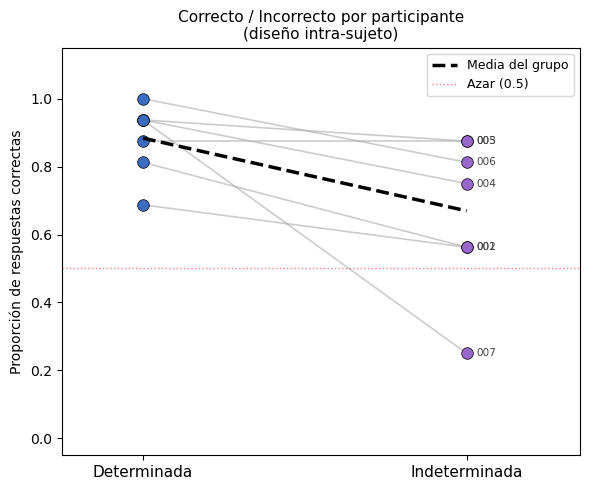


[Variable 'prop_correctas' disponible para pruebas estadísticas en pasos posteriores.]


In [13]:
# ============================================================
# SECCIÓN 8: CORRECTO / INCORRECTO — SOLO DESCRIPTIVO
# config_valida: True = correcto, False = incorrecto
# No se aplican pruebas estadísticas aquí — queda preparado
# para la comparación determinadas vs indeterminadas posterior
# ============================================================

df['respuesta_correcta'] = df['config_valida'].astype(bool)

# Proporción por participante y condición
prop_correctas = (
    df.groupby(['participante', 'tipo_metafora'])['respuesta_correcta']
    .agg(n_ensayos='count', n_correctas='sum', prop_correctas='mean')
    .round(4)
    .reset_index()
)

print("=" * 70)
print("PROPORCIÓN DE RESPUESTAS CORRECTAS POR PARTICIPANTE Y CONDICIÓN")
print("(Solo descriptivos — pruebas estadísticas pendientes)")
print("=" * 70)
print(prop_correctas.to_string(index=False))

# Resumen global por condición
resumen_corr = (
    prop_correctas.groupby('tipo_metafora')['prop_correctas']
    .agg(media='mean', mediana='median', sd='std')
    .round(4)
)
print("\nResumen por condición:")
print(resumen_corr.to_string())

# ── Figura: gráfico pareado (slope plot) ─────────────────────
# Con n=7 y datos no normales, el gráfico de pendientes
# muestra la dirección individual de cada participante,
# lo cual es más informativo que medias agregadas.
col_det  = '#3A6DC2'   # azul  — determinada
col_ind  = '#9966CC'   # lila  — indeterminada

# Formato ancho para facilitar el trazado de líneas
prop_wide = prop_correctas.pivot_table(
    index='participante', columns='tipo_metafora', values='prop_correctas'
).reset_index()

fig, ax = plt.subplots(figsize=(6, 5))

# Líneas por participante
for _, row in prop_wide.iterrows():
    det_val = row.get('determinada', np.nan)
    ind_val = row.get('indeterminada', np.nan)
    if pd.isna(det_val) or pd.isna(ind_val):
        continue
    color_linea = '#AAAAAA'
    # Verde si aumenta en det, rojo si disminuye — solo para la línea
    ax.plot([0, 1], [det_val, ind_val],
            color=color_linea, linewidth=1.2, alpha=0.6, zorder=1)
    ax.scatter([0], [det_val], color=col_det, s=70,
               edgecolors='black', linewidths=0.5, zorder=3)
    ax.scatter([1], [ind_val], color=col_ind, s=70,
               edgecolors='black', linewidths=0.5, zorder=3)
    # Etiqueta del participante
    ax.text(1.03, ind_val, row['participante'],
            va='center', fontsize=7.5, color='#444444')

# Medias por condición
media_det = prop_wide['determinada'].mean() if 'determinada' in prop_wide else np.nan
media_ind = prop_wide['indeterminada'].mean() if 'indeterminada' in prop_wide else np.nan
ax.plot([0, 1], [media_det, media_ind],
        color='black', linewidth=2.5, linestyle='--',
        label='Media del grupo', zorder=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Determinada', 'Indeterminada'], fontsize=11)
ax.set_xlim(-0.25, 1.35)
ax.set_ylim(-0.05, 1.15)
ax.set_ylabel('Proporción de respuestas correctas')
ax.set_title('Correcto / Incorrecto por participante\n(diseño intra-sujeto)', fontsize=11)
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Azar (0.5)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n[Variable 'prop_correctas' disponible para pruebas estadísticas en pasos posteriores.]")

---
## Sección 9: Análisis descriptivo por sexo

> ⚠️ **Solo exploratorio.** La muestra total es muy pequeña (n ≤ 7) y los subgrupos por sexo tienen n insuficiente para cualquier prueba inferencial con poder estadístico aceptable. No se deben extraer conclusiones sobre diferencias por sexo.

In [8]:
# ============================================================
# SECCIÓN 9: ANÁLISIS DESCRIPTIVO POR SEXO — SOLO EXPLORATORIO
#
# NOTA METODOLÓGICA: La muestra es demasiado pequeña para
# realizar pruebas estadísticas por sexo. Los grupos tendrían
# n ≤ 4 por sexo, lo que hace imposible obtener estimaciones
# robustas. Este bloque es puramente descriptivo.
# ============================================================

# Un registro por participante (evitar duplicados por ensayo)
info_sujetos = (
    df.drop_duplicates('participante')[['participante', 'sexo', 'edad']]
    .sort_values('participante')
    .reset_index(drop=True)
)

print("=" * 70)
print("ANÁLISIS DESCRIPTIVO POR SEXO (solo exploratorio)")
print("[NO hacer inferencias estadísticas por sexo — muestra muy pequeña]")
print("=" * 70)

print("\nNúmero de participantes por sexo:")
print(info_sujetos['sexo'].value_counts().to_string())

print("\nDetalle de participantes:")
print(info_sujetos.to_string(index=False))

# Medias de variables continuas por sexo y condición
medias_sexo = (
    df.groupby(['sexo', 'tipo_metafora'])[VARS_ANALISIS]
    .mean()
    .round(4)
)
print("\nMedias por sexo y tipo de metáfora:")
print(medias_sexo.to_string())

# Proporción de correctas por sexo y condición
prop_sexo = (
    df.groupby(['sexo', 'tipo_metafora'])['respuesta_correcta']
    .agg(n='count', prop_correctas='mean')
    .round(4)
)
print("\nProporción de correctas por sexo y condición:")
print(prop_sexo.to_string())

print("\n[Con grupos tan pequeños por sexo, se omiten pruebas estadísticas para esta variable.]")

ANÁLISIS DESCRIPTIVO POR SEXO (solo exploratorio)
[NO hacer inferencias estadísticas por sexo — muestra muy pequeña]

Número de participantes por sexo:
sexo
Masculino    4
Femenino     3

Detalle de participantes:
participante      sexo  edad
         001 Masculino    19
         002  Femenino    21
         003 Masculino    24
         004  Femenino    21
         005 Masculino    19
         006 Masculino    25
         007  Femenino    22

Medias por sexo y tipo de metáfora:
                         rt_lectura_s  rt_inferencia_s  total_score  parcial_score
sexo      tipo_metafora                                                           
Femenino  determinada         25.3690           6.2600      85.4167        86.4583
          indeterminada       15.0306           5.1681      52.0833        54.1667
Masculino determinada          9.3919           6.0263      90.6250        96.0938
          indeterminada       13.9694           6.8038      78.1250        86.7188

Proporción de corr

---
## Sección 10: Selección de prueba inferencial

El análisis llega hasta aquí (Pasos 1–3). Modifica `prueba_elegida` en la celda siguiente para continuar.

In [9]:
# ============================================================
# SECCIÓN 10: PAUSA — RESUMEN Y PREGUNTA FINAL
# ============================================================

print("=" * 70)
print("RESUMEN — PASOS COMPLETADOS:")
print("  ✓  Paso 1 — Descriptivos por condición (media, SD, mediana, RIQ)")
print("  ✓  Paso 2 — Promedios por participante y condición")
print("  ✓  Paso 3 — Shapiro-Wilk sobre diferencias entre condiciones")
print("  ✓  (adicional) Correcto/Incorrecto — descriptivos preparados")
print("  ✓  (adicional) Análisis exploratorio por sexo")
print("=" * 70)
print()
print("Ya se calcularon los descriptivos, los promedios por participante")
print("y la prueba de normalidad Shapiro-Wilk.")
print()
print("¿Quieres continuar con:")
print("   'student'   →  t de Student pareada")
print("   'wilcoxon'  →  Wilcoxon signed-rank")
print("   'ambas'     →  ambas pruebas")
print()
print("Modifica la variable 'prueba_elegida' en la celda siguiente y ejecútala.")
print("=" * 70)

RESUMEN — PASOS COMPLETADOS:
  ✓  Paso 1 — Descriptivos por condición (media, SD, mediana, RIQ)
  ✓  Paso 2 — Promedios por participante y condición
  ✓  Paso 3 — Shapiro-Wilk sobre diferencias entre condiciones
  ✓  (adicional) Correcto/Incorrecto — descriptivos preparados
  ✓  (adicional) Análisis exploratorio por sexo

Ya se calcularon los descriptivos, los promedios por participante
y la prueba de normalidad Shapiro-Wilk.

¿Quieres continuar con:
   'student'   →  t de Student pareada
   'wilcoxon'  →  Wilcoxon signed-rank
   'ambas'     →  ambas pruebas

Modifica la variable 'prueba_elegida' en la celda siguiente y ejecútala.


In [11]:
# ── Modifica esta variable y ejecuta la celda para continuar ──────────────
# Opciones válidas: 'student'  |  'wilcoxon'  |  'ambas'
prueba_elegida = 'wilcoxon'  # <── cambia None por tu elección

# ──────────────────────────────────────────────────────────────────────────
if prueba_elegida is None:
    print("[Pendiente] Modifica 'prueba_elegida' arriba y ejecuta esta celda.")
elif str(prueba_elegida).lower() in ('student', 'wilcoxon', 'ambas'):
    print(f"✓  Seleccionado: '{prueba_elegida}'.")
    print("   Crea la siguiente celda e implementa la prueba elegida sobre 'df_wide'.")
    print("   Variables de diferencia disponibles:", nombres_dif)
else:
    print(f"[Error] '{prueba_elegida}' no es válido. Usa 'student', 'wilcoxon' o 'ambas'.")

✓  Seleccionado: 'wilcoxon'.
   Crea la siguiente celda e implementa la prueba elegida sobre 'df_wide'.
   Variables de diferencia disponibles: ['diferencia_rt_lectura', 'diferencia_rt_inferencia', 'diferencia_total_score', 'diferencia_parcial_score']


---
## Sección 11: Wilcoxon signed-rank

Prueba no paramétrica para muestras pareadas. Se aplica sobre los **promedios por participante** (`df_wide`), usando las mismas diferencias calculadas en la Sección 7.

- H₀: la mediana de las diferencias es 0 (no hay efecto de la condición)
- H₁: la mediana es distinta de 0
- α = 0.05 (bilateral)

> Alternativa no paramétrica a la t de Student pareada. Apropiada cuando la distribución de las diferencias no es normal, como indica Shapiro-Wilk para la mayoría de las variables.

WILCOXON SIGNED-RANK — DIFERENCIAS ENTRE CONDICIONES
(Basado en promedios por participante — diseño intra-sujeto)
α = 0.05  |  H₀: mediana de diferencias = 0  |  bilateral
       variable                  comparacion  n       W  p_value sig_p05  mediana_a  mediana_b
   rt_lectura_s indeterminada vs determinada  7 12.0000   0.8125    ✗ NO    11.8905     9.7363
rt_inferencia_s indeterminada vs determinada  7 12.0000   0.8125    ✗ NO     5.9794     5.6196
    total_score determinada vs indeterminada  7  0.0000   0.0273    ✓ SÍ    93.7500    75.0000
  parcial_score determinada vs indeterminada  7  0.0000   0.0273    ✓ SÍ    93.7500    78.1250


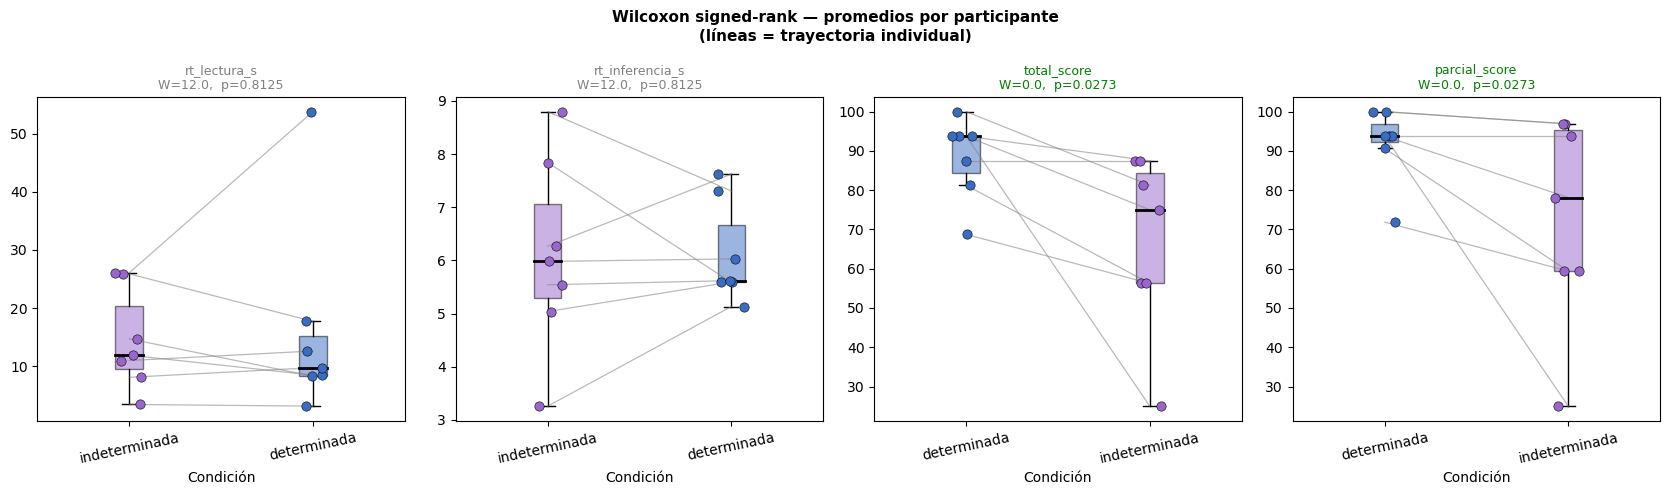


[Fin del análisis planificado. No se hacen conclusiones definitivas en esta etapa.]


In [14]:
# ============================================================
# SECCIÓN 11: WILCOXON SIGNED-RANK
# Prueba no paramétrica intra-sujeto (n=7, diferencias no normales)
# Se usa stats.wilcoxon con alternative='two-sided'
# ============================================================

print("=" * 70)
print("WILCOXON SIGNED-RANK — DIFERENCIAS ENTRE CONDICIONES")
print("(Basado en promedios por participante — diseño intra-sujeto)")
print("α = 0.05  |  H₀: mediana de diferencias = 0  |  bilateral")
print("=" * 70)

# Configuración de las columnas a comparar (misma dirección que Shapiro)
wilcox_config = {
    'diferencia_rt_lectura':    ('rt_lectura_s_indeterminada',  'rt_lectura_s_determinada',
                                 'indeterminada', 'determinada',  'rt_lectura_s'),
    'diferencia_rt_inferencia': ('rt_inferencia_s_indeterminada','rt_inferencia_s_determinada',
                                 'indeterminada', 'determinada',  'rt_inferencia_s'),
    'diferencia_total_score':   ('total_score_determinada',     'total_score_indeterminada',
                                 'determinada',  'indeterminada', 'total_score'),
    'diferencia_parcial_score': ('parcial_score_determinada',   'parcial_score_indeterminada',
                                 'determinada',  'indeterminada', 'parcial_score'),
}

resultados_wil = []
for nombre_dif, (col_a, col_b, label_a, label_b, var_nombre) in wilcox_config.items():
    if col_a not in df_wide.columns or col_b not in df_wide.columns:
        print(f"[!] Columnas no encontradas para {nombre_dif}, se omite.")
        continue
    x = df_wide[col_a].dropna()
    y = df_wide[col_b].dropna()
    # Alinear índices
    idx = x.index.intersection(y.index)
    x, y = x.loc[idx], y.loc[idx]
    n = len(x)

    if n < 4:
        print(f"[!] {nombre_dif}: n={n} insuficiente para Wilcoxon.")
        continue

    W_stat, p_val = stats.wilcoxon(x, y, alternative='two-sided')
    sig = '✓ SÍ' if p_val < 0.05 else '✗ NO'
    resultados_wil.append({
        'variable':       var_nombre,
        'comparacion':    f'{label_a} vs {label_b}',
        'n':              n,
        'W':              round(W_stat, 3),
        'p_value':        round(p_val, 4),
        'sig_p05':        sig,
        'mediana_a':      round(x.median(), 4),
        'mediana_b':      round(y.median(), 4),
    })

df_wilcox = pd.DataFrame(resultados_wil)
print(df_wilcox.to_string(index=False))

# ── Figura: box plots pareados con líneas de participante ────
n_res = len(df_wilcox)
if n_res > 0:
    fig, axes = plt.subplots(1, n_res, figsize=(4.2 * n_res, 5))
    if n_res == 1:
        axes = [axes]

    col_det_w = '#3A6DC2'
    col_ind_w = '#9966CC'
    rng2 = np.random.default_rng(7)

    for ax, (_, row) in zip(axes, df_wilcox.iterrows()):
        var = row['variable']
        comp = row['comparacion'].split(' vs ')
        label_a, label_b = comp[0].strip(), comp[1].strip()
        col_a_k = f"{var}_{label_a}"
        col_b_k = f"{var}_{label_b}"
        vals_a = df_wide[col_a_k].dropna().values
        vals_b = df_wide[col_b_k].dropna().values
        n_pts  = min(len(vals_a), len(vals_b))

        colores_w = [col_det_w if label_a == 'determinada' else col_ind_w,
                     col_det_w if label_b == 'determinada' else col_ind_w]

        bp = ax.boxplot(
            [vals_a, vals_b],
            labels=[label_a, label_b],
            patch_artist=True, notch=False,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker=''),
        )
        for patch, c in zip(bp['boxes'], colores_w):
            patch.set_facecolor(c)
            patch.set_alpha(0.5)

        # Líneas de participante
        for j in range(n_pts):
            ax.plot([1, 2], [vals_a[j], vals_b[j]],
                    color='gray', linewidth=0.9, alpha=0.55, zorder=2)
        # Puntos
        jit_a = rng2.uniform(-0.08, 0.08, n_pts)
        jit_b = rng2.uniform(-0.08, 0.08, n_pts)
        ax.scatter(1 + jit_a, vals_a, color=colores_w[0], s=45,
                   edgecolors='black', linewidths=0.4, zorder=3)
        ax.scatter(2 + jit_b, vals_b, color=colores_w[1], s=45,
                   edgecolors='black', linewidths=0.4, zorder=3)

        # Etiqueta del p-value
        p_etiq = f"W={row['W']},  p={row['p_value']}"
        color_p = 'green' if row['sig_p05'].startswith('✓') else 'gray'
        ax.set_title(f"{var}\n{p_etiq}", fontsize=9, color=color_p)
        ax.set_xlabel('Condición')
        ax.tick_params(axis='x', rotation=12)

    fig.suptitle('Wilcoxon signed-rank — promedios por participante\n(líneas = trayectoria individual)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n[Fin del análisis planificado. No se hacen conclusiones definitivas en esta etapa.]")